In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

Load Dataset

In [4]:
df=pd.read_csv("train (1).csv")
df1=pd.read_csv("test (1).csv")
df.head()



,ID,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,subscribed
0,26110,56,admin.,married,unknown,no,1933,no,no,telephone,19,nov,44,2,-1,0,unknown,no
1,40576,31,unknown,married,secondary,no,3,no,no,cellular,20,jul,91,2,-1,0,unknown,no
2,15320,27,services,married,secondary,no,891,yes,no,cellular,18,jul,240,1,-1,0,unknown,no
3,43962,57,management,divorced,tertiary,no,3287,no,no,cellular,22,jun,867,1,84,3,success,yes
4,29842,31,technician,married,secondary,no,119,yes,no,cellular,4,feb,380,1,-1,0,unknown,no


In [6]:
df.tail()


,ID,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,subscribed
31642,36483,29,management,single,tertiary,no,0,yes,no,cellular,12,may,116,2,-1,0,unknown,no
31643,40178,53,management,divorced,tertiary,no,380,no,yes,cellular,5,jun,438,2,-1,0,unknown,yes
31644,19710,32,management,single,tertiary,no,312,no,no,cellular,7,aug,37,3,-1,0,unknown,no
31645,38556,57,technician,married,secondary,no,225,yes,no,telephone,15,may,22,7,337,12,failure,no
31646,14156,55,management,divorced,secondary,no,204,yes,no,cellular,11,jul,1973,2,-1,0,unknown,yes


In [8]:
df.shape


(31647, 18)

In [10]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31647 entries, 0 to 31646
Data columns (total 18 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   ID          31647 non-null  int64 
 1   age         31647 non-null  int64 
 2   job         31647 non-null  object
 3   marital     31647 non-null  object
 4   education   31647 non-null  object
 5   default     31647 non-null  object
 6   balance     31647 non-null  int64 
 7   housing     31647 non-null  object
 8   loan        31647 non-null  object
 9   contact     31647 non-null  object
 10  day         31647 non-null  int64 
 11  month       31647 non-null  object
 12  duration    31647 non-null  int64 
 13  campaign    31647 non-null  int64 
 14  pdays       31647 non-null  int64 
 15  previous    31647 non-null  int64 
 16  poutcome    31647 non-null  object
 17  subscribed  31647 non-null  object
dtypes: int64(8), object(10)
memory usage: 4.3+ MB


In [12]:
df.isnull().sum()


ID            0
age           0
job           0
marital       0
education     0
default       0
balance       0
housing       0
loan          0
contact       0
day           0
month         0
duration      0
campaign      0
pdays         0
previous      0
poutcome      0
subscribed    0
dtype: int64

In [14]:
print(df.dtypes)


ID             int64
age            int64
job           object
marital       object
education     object
default       object
balance        int64
housing       object
loan          object
contact       object
day            int64
month         object
duration       int64
campaign       int64
pdays          int64
previous       int64
poutcome      object
subscribed    object
dtype: object


Find duplicated values

In [17]:
df.duplicated().sum()


0

Identifiying garbage values

In [20]:
for col in df.columns:
    print(f'{col} has {len(df[col].unique())} unique values')


ID has 31647 unique values
age has 76 unique values
job has 12 unique values
marital has 3 unique values
education has 4 unique values
default has 2 unique values
balance has 6326 unique values
housing has 2 unique values
loan has 2 unique values
contact has 3 unique values
day has 31 unique values
month has 12 unique values
duration has 1454 unique values
campaign has 45 unique values
pdays has 509 unique values
previous has 38 unique values
poutcome has 4 unique values
subscribed has 2 unique values


In [22]:
df.replace(['?', 'p', 'none', 'N/A', 'null', 'NA', ' '], np.nan, inplace=True)

In [24]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,31647.0,22563.972162,13075.936990,2.0,11218.0,22519.0,33879.5,45211.0
age,31647.0,40.957247,10.625134,18.0,33.0,39.0,48.0,95.0
balance,31647.0,1363.890258,3028.304293,-8019.0,73.0,450.0,1431.0,102127.0
day,31647.0,15.835466,8.337097,1.0,8.0,16.0,21.0,31.0
duration,31647.0,258.113534,257.118973,0.0,104.0,180.0,318.5,4918.0
campaign,31647.0,2.765697,3.113830,1.0,1.0,2.0,3.0,63.0
pdays,31647.0,39.576042,99.317592,-1.0,-1.0,-1.0,-1.0,871.0
previous,31647.0,0.574272,2.422529,0.0,0.0,0.0,0.0,275.0


Encoding

In [27]:
from sklearn.preprocessing import LabelEncoder

In [28]:
df['job']=LabelEncoder().fit_transform(df['job'])
df['marital']=LabelEncoder().fit_transform(df['marital'])
df['education']=LabelEncoder().fit_transform(df['education'])
df['default']=LabelEncoder().fit_transform(df['default'])
df['housing']=LabelEncoder().fit_transform(df['housing'])
df['loan']=LabelEncoder().fit_transform(df['loan'])
df['contact']=LabelEncoder().fit_transform(df['contact'])
df['month']=LabelEncoder().fit_transform(df['month'])
df['poutcome']=LabelEncoder().fit_transform(df['poutcome'])
df['subscribed']=LabelEncoder().fit_transform(df['subscribed'])



In [31]:
df.head()

,ID,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,subscribed
0,26110,56,0,1,3,0,1933,0,0,1,19,9,44,2,-1,0,3,0
1,40576,31,11,1,1,0,3,0,0,0,20,5,91,2,-1,0,3,0
2,15320,27,7,1,1,0,891,1,0,0,18,5,240,1,-1,0,3,0
3,43962,57,4,0,2,0,3287,0,0,0,22,6,867,1,84,3,2,1
4,29842,31,9,1,1,0,119,1,0,0,4,3,380,1,-1,0,3,0


In [33]:
df1.columns
print(df1.dtypes)

ID            int64
age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
dtype: object


In [35]:
df1['job']=LabelEncoder().fit_transform(df1['job'])
df1['marital']=LabelEncoder().fit_transform(df1['marital'])
df1['education']=LabelEncoder().fit_transform(df1['education'])
df1['default']=LabelEncoder().fit_transform(df1['default'])
df1['housing']=LabelEncoder().fit_transform(df1['housing'])
df1['loan']=LabelEncoder().fit_transform(df1['loan'])
df1['contact']=LabelEncoder().fit_transform(df1['contact'])
df1['month']=LabelEncoder().fit_transform(df1['month'])
df1['poutcome']=LabelEncoder().fit_transform(df1['poutcome'])


In [37]:
df1.head()

,ID,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome
0,38441,32,7,1,1,0,118,1,0,0,15,8,20,6,-1,0,3
1,40403,78,5,0,0,0,2787,0,0,1,1,5,372,1,-1,0,3
2,3709,31,6,2,2,0,144,1,0,2,16,8,676,1,-1,0,3
3,37422,57,7,2,0,0,3777,1,0,1,13,8,65,2,-1,0,3
4,12527,45,1,0,1,0,-705,0,1,2,3,5,111,1,-1,0,3


Boxplot

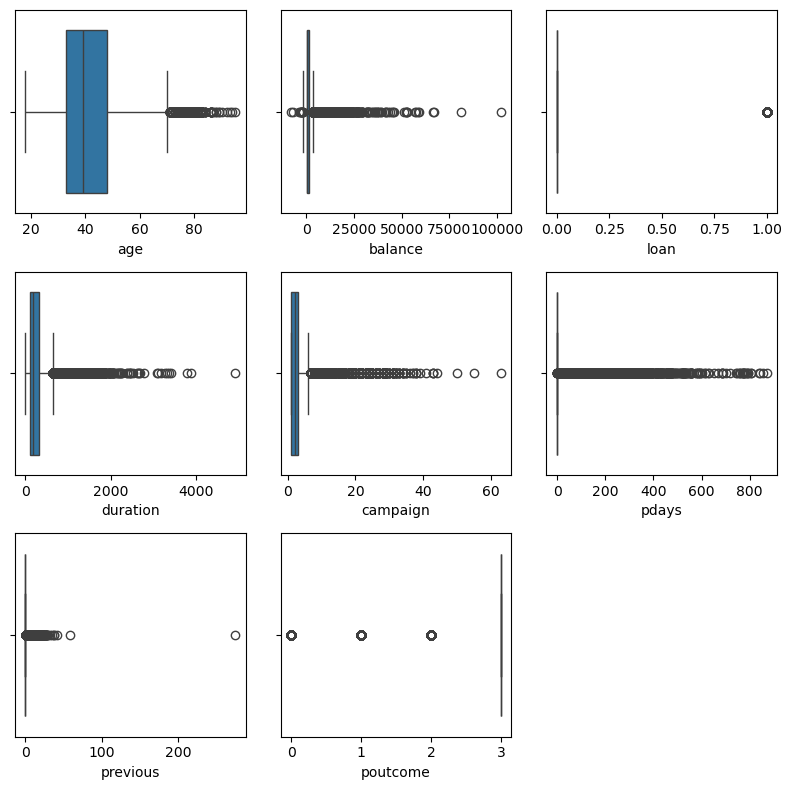

In [40]:
plt.figure(figsize=(8,8))
plt.subplot(3,3,1)
sns.boxplot(x=df["age"])
plt.subplot(3,3,2)
sns.boxplot(x=df["balance"])
plt.subplot(3,3,3)
sns.boxplot(x=df["loan"])
plt.subplot(3,3,4)
sns.boxplot(x=df["duration"])
plt.subplot(3,3,5)
sns.boxplot(x=df["campaign"])
plt.subplot(3,3,6)
sns.boxplot(x=df["pdays"])
plt.subplot(3,3,7)
sns.boxplot(x=df["previous"])
plt.subplot(3,3,8)
sns.boxplot(x=df["poutcome"])
plt.tight_layout()            
plt.show()
            


Boxplot

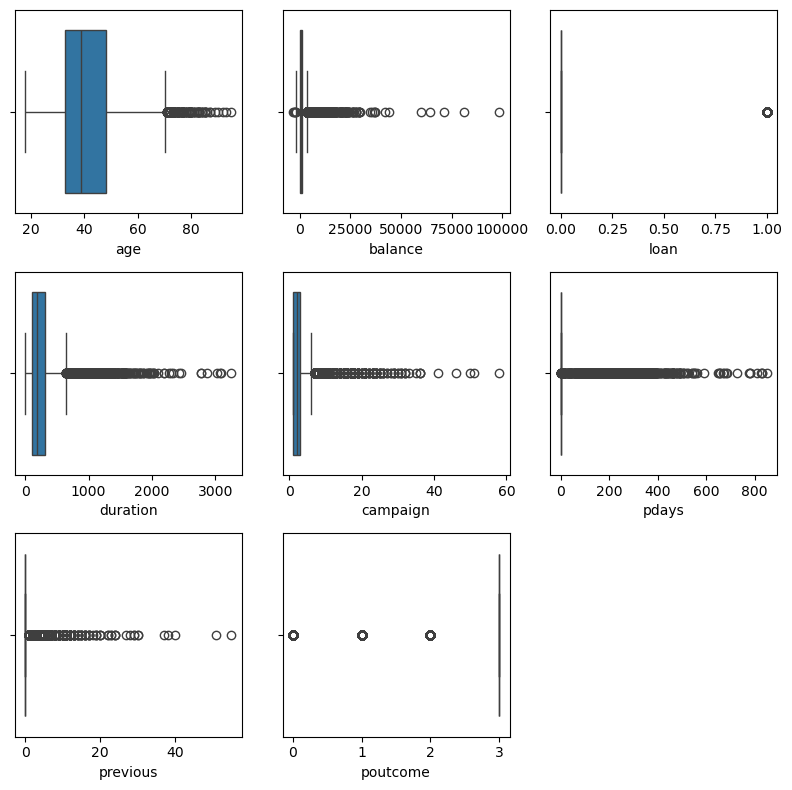

In [43]:
plt.figure(figsize=(8,8))
plt.subplot(3,3,1)
sns.boxplot(x=df1["age"])
plt.subplot(3,3,2)
sns.boxplot(x=df1["balance"])
plt.subplot(3,3,3)
sns.boxplot(x=df1["loan"])
plt.subplot(3,3,4)
sns.boxplot(x=df1["duration"])
plt.subplot(3,3,5)
sns.boxplot(x=df1["campaign"])
plt.subplot(3,3,6)
sns.boxplot(x=df1["pdays"])
plt.subplot(3,3,7)
sns.boxplot(x=df1["previous"])
plt.subplot(3,3,8)
sns.boxplot(x=df1["poutcome"])
plt.tight_layout()            
plt.show()
            


Outliers


In [46]:
#calculate Q1 and Q3 for the column age
Q1=df['age'].quantile(0.25)
Q3=df['age'].quantile(0.75)
print(Q1)
print(Q3)

#calculate IQR
IQR=Q3-Q1
print(IQR)

#calculate Lower and Upper fence
lower_fence_age=Q1 - 1.5 * IQR
upper_fence_age=Q3 + 1.5 * IQR

#print the fences
print("Lower fence:", lower_fence_age)
print("Upper fence:", upper_fence_age)



33.0
48.0
15.0
Lower fence: 10.5
Upper fence: 70.5


In [48]:
#calculate Q1 and Q3 for the column balance
Q1=df['balance'].quantile(0.25)
Q3=df['balance'].quantile(0.75)
print(Q1)
print(Q3)

#calculate IQR
IQR=Q3-Q1
print(IQR)

#calculate Lower and Upper fence
lower_fence_balance=Q1 - 1.5 * IQR
upper_fence_balance=Q3 + 1.5 * IQR

#print the fences
print("Lower fence:", lower_fence_balance)
print("Upper fence:", upper_fence_balance)





73.0
1431.0
1358.0
Lower fence: -1964.0
Upper fence: 3468.0


In [50]:
#calculate Q1 and Q3 for the column loan
Q1=df['loan'].quantile(0.25)
Q3=df['loan'].quantile(0.75)
print(Q1)
print(Q3)

#calculate IQR
IQR=Q3-Q1
print(IQR)

#calculate Lower and Upper fence
lower_fence_loan=Q1 - 1.5 * IQR
upper_fence_loan=Q3 + 1.5 * IQR

#print the fences
print("Lower fence:", lower_fence_loan)
print("Upper fence:", upper_fence_loan)


0.0
0.0
0.0
Lower fence: 0.0
Upper fence: 0.0


In [52]:
#calculate Q1 and Q3 for the column duration
Q1=df['duration'].quantile(0.25)
Q3=df['duration'].quantile(0.75)
print(Q1)
print(Q3)

#calculate IQR
IQR=Q3-Q1
print(IQR)

#calculate Lower and Upper fence
lower_fence_duration=Q1 - 1.5 * IQR
upper_fence_duration=Q3 + 1.5 * IQR

#print the fences
print("Lower fence:", lower_fence_duration)
print("Upper fence:", upper_fence_duration)


104.0
318.5
214.5
Lower fence: -217.75
Upper fence: 640.25


In [54]:
#calculate Q1 and Q3 for the column campaign
Q1=df['campaign'].quantile(0.25)
Q3=df['campaign'].quantile(0.75)
print(Q1)
print(Q3)

#calculate IQR
IQR=Q3-Q1
print(IQR)

#calculate Lower and Upper fence
lower_fence_campaign=Q1 - 1.5 * IQR
upper_fence_campaign=Q3 + 1.5 * IQR

#print the fences
print("Lower fence:", lower_fence_campaign)
print("Upper fence:", upper_fence_campaign)

1.0
3.0
2.0
Lower fence: -2.0
Upper fence: 6.0


In [56]:
#calculate Q1 and Q3 for the column pdays
Q1=df['pdays'].quantile(0.25)
Q3=df['pdays'].quantile(0.75)
print(Q1)
print(Q3)

#calculate IQR
IQR=Q3-Q1
print(IQR)

#calculate Lower and Upper fence
lower_fence_pdays=Q1 - 1.5 * IQR
upper_fence_pdays=Q3 + 1.5 * IQR

#print the fences
print("Lower fence:", lower_fence_pdays)
print("Upper fence:", upper_fence_pdays)

-1.0
-1.0
0.0
Lower fence: -1.0
Upper fence: -1.0


In [58]:
#calculate Q1 and Q3 for the column previous
Q1=df['previous'].quantile(0.25)
Q3=df['previous'].quantile(0.75)
print(Q1)
print(Q3)

#calculate IQR
IQR=Q3-Q1
print(IQR)

#calculate Lower and Upper fence
lower_fence_previous=Q1 - 1.5 * IQR
upper_fence_previous=Q3 + 1.5 * IQR

#print the fences
print("Lower fence:", lower_fence_previous)
print("Upper fence:", upper_fence_previous)

0.0
0.0
0.0
Lower fence: 0.0
Upper fence: 0.0


In [60]:
#calculate Q1 and Q3 for the column poutcome
Q1=df['poutcome'].quantile(0.25)
Q3=df['poutcome'].quantile(0.75)
print(Q1)
print(Q3)

#calculate IQR
IQR=Q3-Q1
print(IQR)

#calculate Lower and Upper fence
lower_fence_poutcome=Q1 - 1.5 * IQR
upper_fence_poutcome=Q3 + 1.5 * IQR

#print the fences
print("Lower fence:", lower_fence_poutcome)
print("Upper fence:", upper_fence_poutcome)

3.0
3.0
0.0
Lower fence: 3.0
Upper fence: 3.0


Remove ouliers

In [63]:
df_clean=df[(df['age'] >= lower_fence_age) & (df['age'] <= upper_fence_age)]
df_clean=df[(df['balance'] >= lower_fence_balance) & (df['balance'] <= upper_fence_balance)]
df_clean=df[(df['loan'] >= lower_fence_loan) & (df['loan'] <= upper_fence_loan)]
df_clean=df[(df['duration'] >= lower_fence_duration) & (df['duration'] <= upper_fence_duration)]
df_clean=df[(df['campaign'] >= lower_fence_campaign) & (df['campaign'] <= upper_fence_campaign )]
df_clean=df[(df['pdays'] >= lower_fence_pdays) & (df['pdays'] <= upper_fence_pdays)]
df_clean=df[(df['previous'] >= lower_fence_previous) & (df['previous'] <= upper_fence_previous)]
df_clean=df[(df['poutcome'] >= lower_fence_poutcome) & (df['poutcome'] <= upper_fence_poutcome)]


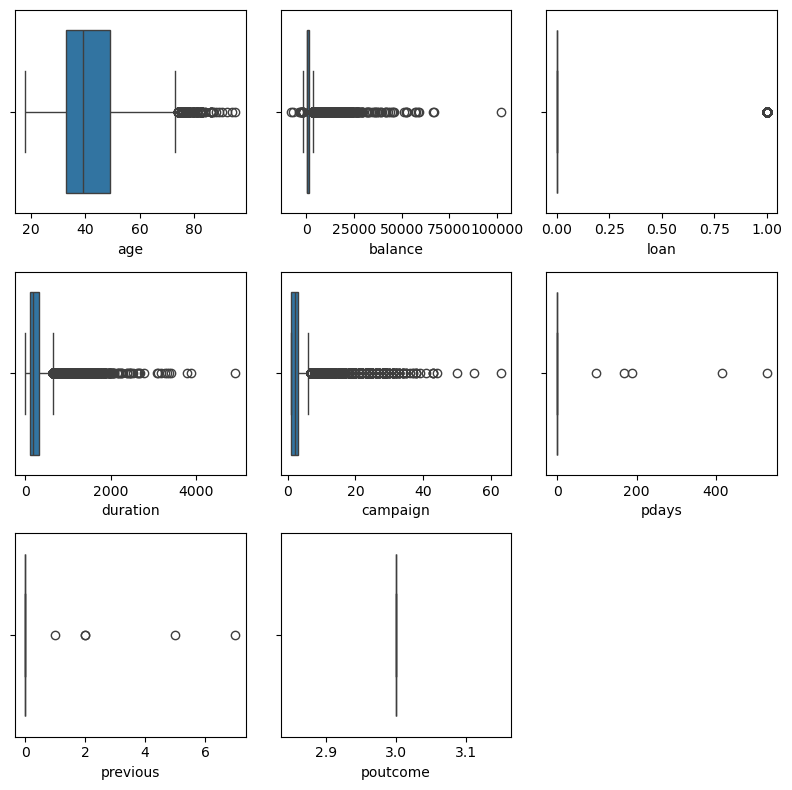

In [65]:
plt.figure(figsize=(8,8))
plt.subplot(3,3,1)
sns.boxplot(x=df_clean["age"])
plt.subplot(3,3,2)
sns.boxplot(x=df_clean["balance"])
plt.subplot(3,3,3)
sns.boxplot(x=df_clean["loan"])
plt.subplot(3,3,4)
sns.boxplot(x=df_clean["duration"])
plt.subplot(3,3,5)
sns.boxplot(x=df_clean["campaign"])
plt.subplot(3,3,6)
sns.boxplot(x=df_clean["pdays"])
plt.subplot(3,3,7)
sns.boxplot(x=df_clean["previous"])
plt.subplot(3,3,8)
sns.boxplot(x=df_clean["poutcome"])
plt.tight_layout()            
plt.show()

Capping

In [68]:
for col in ['age', 'balance', 'loan', 'duration', 'campaign', 'pdays', 'previous', 'poutcome' ]:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_fence = Q1 - 1.5 * IQR
    upper_fence = Q3 + 1.5 * IQR
    capped_col = f'{col}_capped'
    df[capped_col] = df[col]
    df.loc[df[capped_col] > upper_fence, capped_col] = upper_fence
    df.loc[df[capped_col] < lower_fence, capped_col] = lower_fence


<Axes: ylabel='age_capped'>

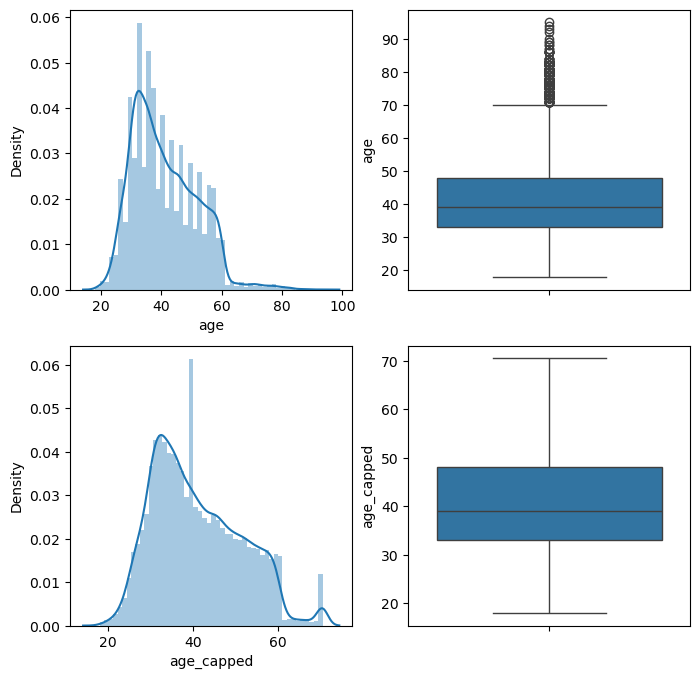

In [70]:
plt.figure(figsize=(8,8))
plt.subplot(2,2,1)
sns.distplot(df["age"])

plt.subplot(2,2,2)
sns.boxplot(df["age"])

plt.subplot(2,2,3)
sns.distplot(df["age_capped"])

plt.subplot(2,2,4)
sns.boxplot(df["age_capped"])

<Axes: ylabel='balance_capped'>

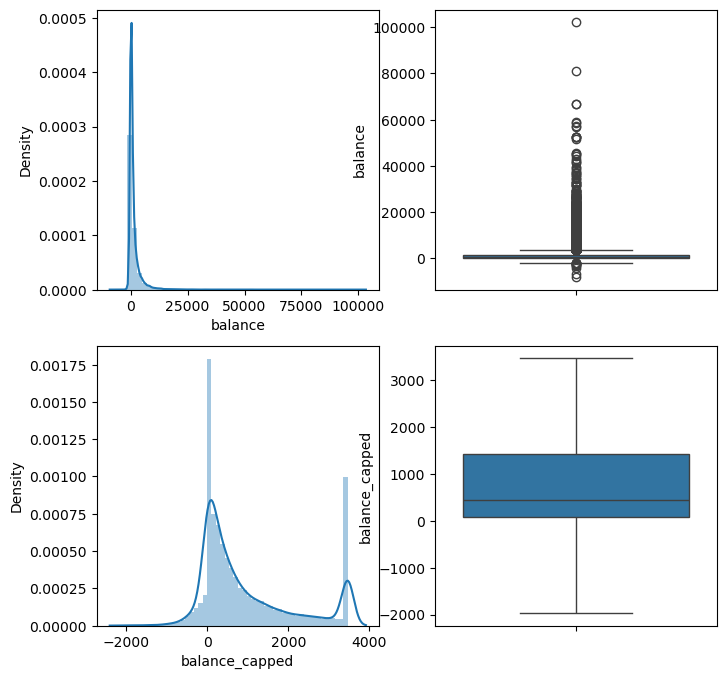

In [71]:
plt.figure(figsize=(8,8))
plt.subplot(2,2,1)
sns.distplot(df["balance"])

plt.subplot(2,2,2)
sns.boxplot(df["balance"])

plt.subplot(2,2,3)
sns.distplot(df["balance_capped"])

plt.subplot(2,2,4)
sns.boxplot(df["balance_capped"])

<Axes: ylabel='loan_capped'>

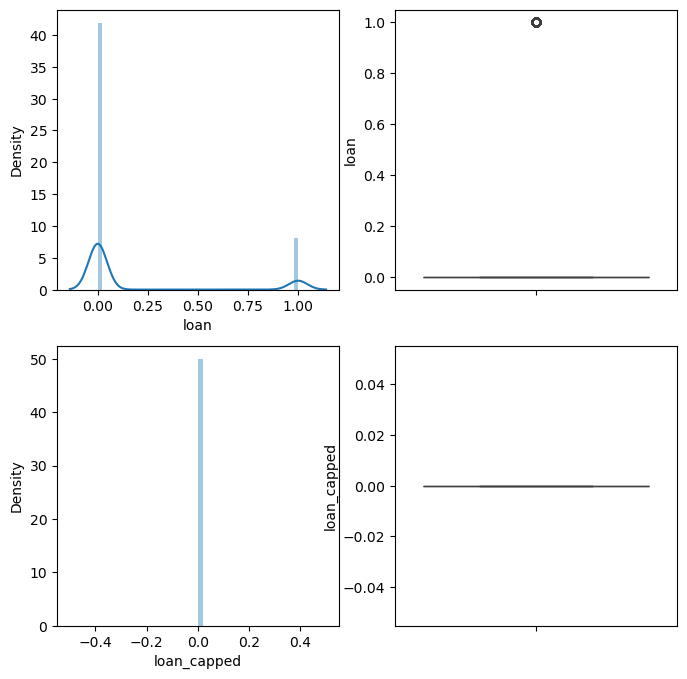

In [73]:
plt.figure(figsize=(8,8))
plt.subplot(2,2,1)
sns.distplot(df["loan"])

plt.subplot(2,2,2)
sns.boxplot(df["loan"])

plt.subplot(2,2,3)
sns.distplot(df["loan_capped"])

plt.subplot(2,2,4)
sns.boxplot(df["loan_capped"])

<Axes: ylabel='duration_capped'>

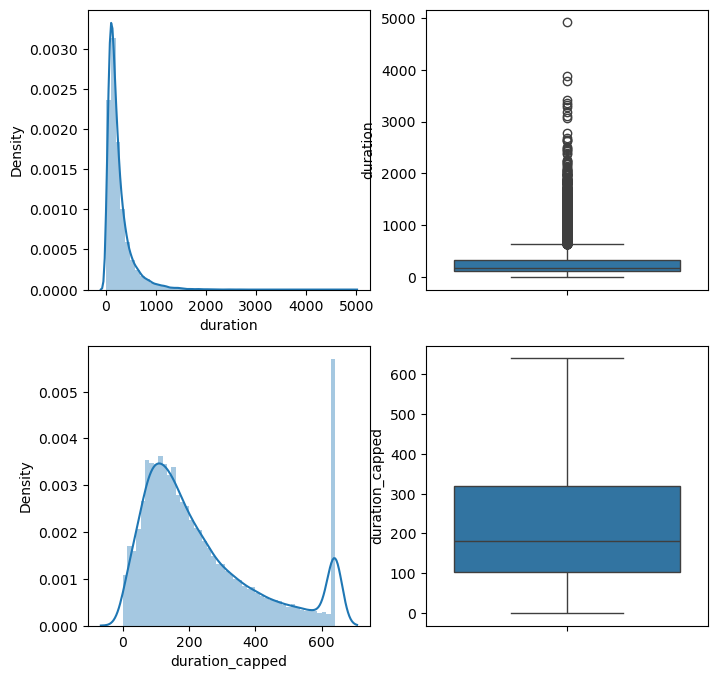

In [74]:
plt.figure(figsize=(8,8))
plt.subplot(2,2,1)
sns.distplot(df["duration"])

plt.subplot(2,2,2)
sns.boxplot(df["duration"])

plt.subplot(2,2,3)
sns.distplot(df["duration_capped"])

plt.subplot(2,2,4)
sns.boxplot(df["duration_capped"])

<Axes: ylabel='campaign_capped'>

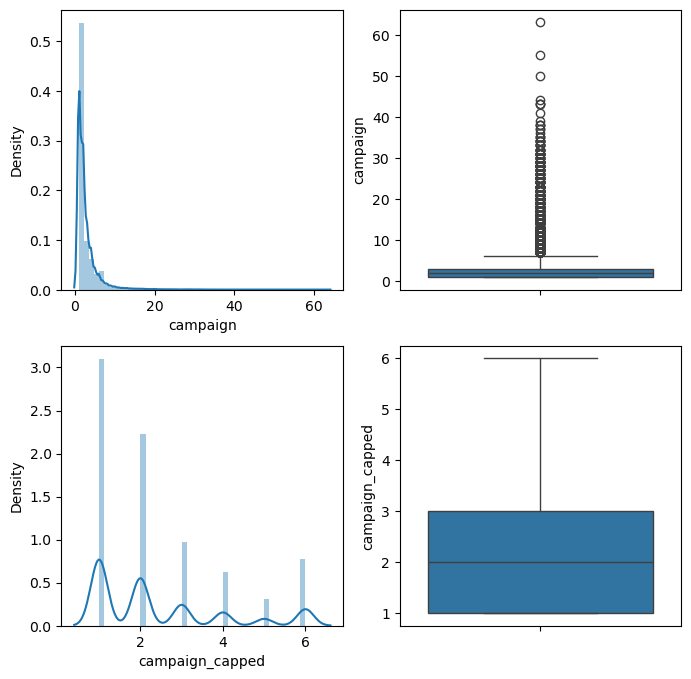

In [76]:
plt.figure(figsize=(8,8))
plt.subplot(2,2,1)
sns.distplot(df["campaign"])

plt.subplot(2,2,2)
sns.boxplot(df["campaign"])

plt.subplot(2,2,3)
sns.distplot(df["campaign_capped"])

plt.subplot(2,2,4)
sns.boxplot(df["campaign_capped"])

<Axes: ylabel='pdays_capped'>

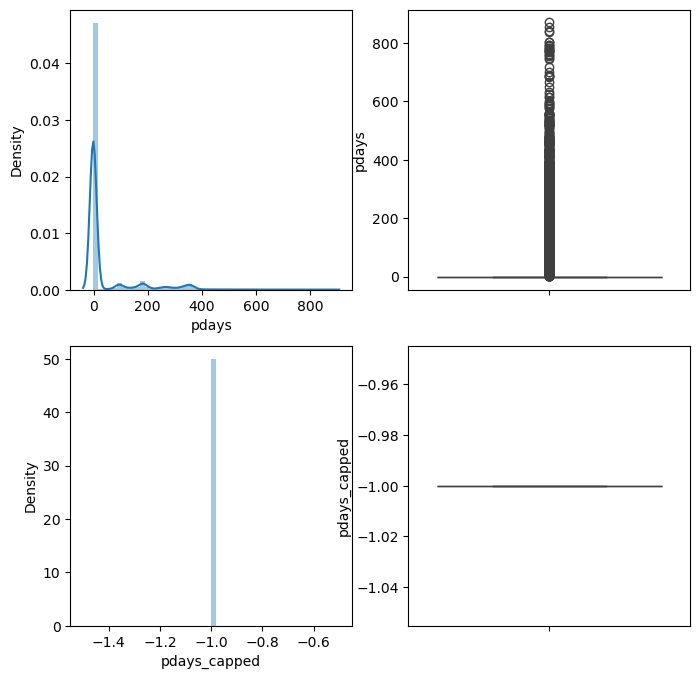

In [78]:
plt.figure(figsize=(8,8))
plt.subplot(2,2,1)
sns.distplot(df["pdays"])

plt.subplot(2,2,2)
sns.boxplot(df["pdays"])

plt.subplot(2,2,3)
sns.distplot(df["pdays_capped"])

plt.subplot(2,2,4)
sns.boxplot(df["pdays_capped"])

<Axes: ylabel='previous_capped'>

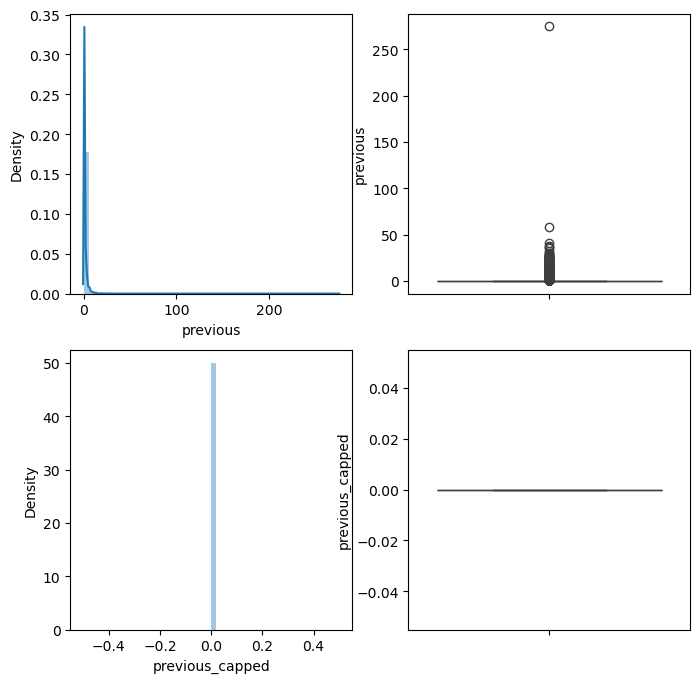

In [79]:
plt.figure(figsize=(8,8))
plt.subplot(2,2,1)
sns.distplot(df["previous"])

plt.subplot(2,2,2)
sns.boxplot(df["previous"])

plt.subplot(2,2,3)
sns.distplot(df["previous_capped"])

plt.subplot(2,2,4)
sns.boxplot(df["previous_capped"])

<Axes: ylabel='poutcome_capped'>

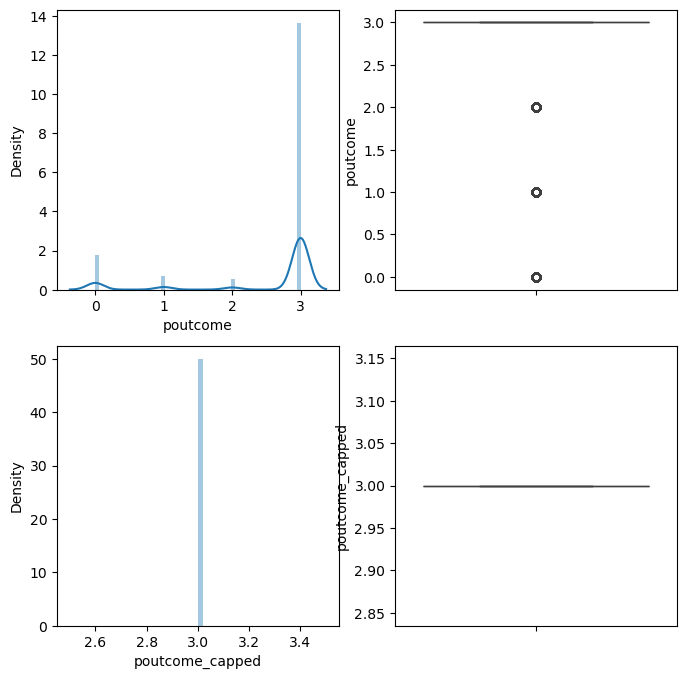

In [81]:
plt.figure(figsize=(8,8))
plt.subplot(2,2,1)
sns.distplot(df["poutcome"])

plt.subplot(2,2,2)
sns.boxplot(df["poutcome"])

plt.subplot(2,2,3)
sns.distplot(df["poutcome_capped"])

plt.subplot(2,2,4)
sns.boxplot(df["poutcome_capped"])

Outliers

In [87]:
#calculate Q1 and Q3 for the column age
Q1=df1['age'].quantile(0.25)
Q3=df1['age'].quantile(0.75)
print(Q1)
print(Q3)

#calculate IQR
IQR=Q3-Q1
print(IQR)

#calculate Lower and Upper fence
lower_fence_age1=Q1 - 1.5 * IQR
upper_fence_age1=Q3 + 1.5 * IQR

#print the fences
print("Lower fence:", lower_fence_age1)
print("Upper fence:", upper_fence_age1)


33.0
48.0
15.0
Lower fence: 10.5
Upper fence: 70.5


In [89]:
#calculate Q1 and Q3 for the column balance
Q1=df1['balance'].quantile(0.25)
Q3=df1['balance'].quantile(0.75)
print(Q1)
print(Q3)

#calculate IQR
IQR=Q3-Q1
print(IQR)

#calculate Lower and Upper fence
lower_fence_balance1=Q1 - 1.5 * IQR
upper_fence_balance1=Q3 + 1.5 * IQR

#print the fences
print("Lower fence:", lower_fence_balance1)
print("Upper fence:", upper_fence_balance1)




71.0
1413.25
1342.25
Lower fence: -1942.375
Upper fence: 3426.625


In [91]:
#calculate Q1 and Q3 for the column loan
Q1=df1['loan'].quantile(0.25)
Q3=df1['loan'].quantile(0.75)
print(Q1)
print(Q3)

#calculate IQR
IQR=Q3-Q1
print(IQR)

#calculate Lower and Upper fence
lower_fence_loan1=Q1 - 1.5 * IQR
upper_fence_loan1=Q3 + 1.5 * IQR

#print the fences
print("Lower fence:", lower_fence_loan1)
print("Upper fence:", upper_fence_loan1)

0.0
0.0
0.0
Lower fence: 0.0
Upper fence: 0.0


In [93]:
#calculate Q1 and Q3 for the column duration
Q1=df1['duration'].quantile(0.25)
Q3=df1['duration'].quantile(0.75)
print(Q1)
print(Q3)

#calculate IQR
IQR=Q3-Q1
print(IQR)

#calculate Lower and Upper fence
lower_fence_duration1=Q1 - 1.5 * IQR
upper_fence_duration1=Q3 + 1.5 * IQR

#print the fences
print("Lower fence:", lower_fence_duration1)
print("Upper fence:", upper_fence_duration1)


102.0
319.0
217.0
Lower fence: -223.5
Upper fence: 644.5


In [95]:
#calculate Q1 and Q3 for the column campaign
Q1=df1['campaign'].quantile(0.25)
Q3=df1['campaign'].quantile(0.75)
print(Q1)
print(Q3)

#calculate IQR
IQR=Q3-Q1
print(IQR)

#calculate Lower and Upper fence
lower_fence_campaign1=Q1 - 1.5 * IQR
upper_fence_campaign1=Q3 + 1.5 * IQR

#print the fences
print("Lower fence:", lower_fence_campaign1)
print("Upper fence:", upper_fence_campaign1)

1.0
3.0
2.0
Lower fence: -2.0
Upper fence: 6.0


In [97]:
#calculate Q1 and Q3 for the column pdays
Q1=df1['pdays'].quantile(0.25)
Q3=df1['pdays'].quantile(0.75)
print(Q1)
print(Q3)

#calculate IQR
IQR=Q3-Q1
print(IQR)

#calculate Lower and Upper fence
lower_fence_pdays1=Q1 - 1.5 * IQR
upper_fence_pdays1=Q3 + 1.5 * IQR

#print the fences
print("Lower fence:", lower_fence_pdays1)
print("Upper fence:", upper_fence_pdays1)

-1.0
-1.0
0.0
Lower fence: -1.0
Upper fence: -1.0


In [99]:
#calculate Q1 and Q3 for the column previous
Q1=df1['previous'].quantile(0.25)
Q3=df1['previous'].quantile(0.75)
print(Q1)
print(Q3)

#calculate IQR
IQR=Q3-Q1
print(IQR)

#calculate Lower and Upper fence
lower_fence_previous1=Q1 - 1.5 * IQR
upper_fence_previous1=Q3 + 1.5 * IQR

#print the fences
print("Lower fence:", lower_fence_previous1)
print("Upper fence:", upper_fence_previous1)

0.0
0.0
0.0
Lower fence: 0.0
Upper fence: 0.0


In [101]:
#calculate Q1 and Q3 for the column poutcome
Q1=df1['poutcome'].quantile(0.25)
Q3=df1['poutcome'].quantile(0.75)
print(Q1)
print(Q3)

#calculate IQR
IQR=Q3-Q1
print(IQR)

#calculate Lower and Upper fence
lower_fence_poutcome1=Q1 - 1.5 * IQR
upper_fence_poutcome1=Q3 + 1.5 * IQR

#print the fences
print("Lower fence:", lower_fence_poutcome1)
print("Upper fence:", upper_fence_poutcome1)

3.0
3.0
0.0
Lower fence: 3.0
Upper fence: 3.0


Remove ouliers

In [104]:
df_clean=df1[(df1['age'] >= lower_fence_age1) & (df1['age'] <= upper_fence_age1)]
df_clean=df1[(df1['balance'] >= lower_fence_balance1) & (df1['balance'] <= upper_fence_balance1)]
df_clean=df1[(df1['loan'] >= lower_fence_loan1) & (df1['loan'] <= upper_fence_loan1)]
df_clean=df1[(df1['duration'] >= lower_fence_duration1) & (df1['duration'] <= upper_fence_duration1)]
df_clean=df1[(df1['campaign'] >= lower_fence_campaign1) & (df1['campaign'] <= upper_fence_campaign1)]
df_clean=df1[(df1['pdays'] >= lower_fence_pdays1) & (df['pdays'] <= upper_fence_pdays1)]
df_clean=df1[(df1['previous'] >= lower_fence_previous1) & (df1['previous'] <= upper_fence_previous1)]
df_clean=df1[(df1['poutcome'] >= lower_fence_poutcome1) & (df1['poutcome'] <= upper_fence_poutcome1)]


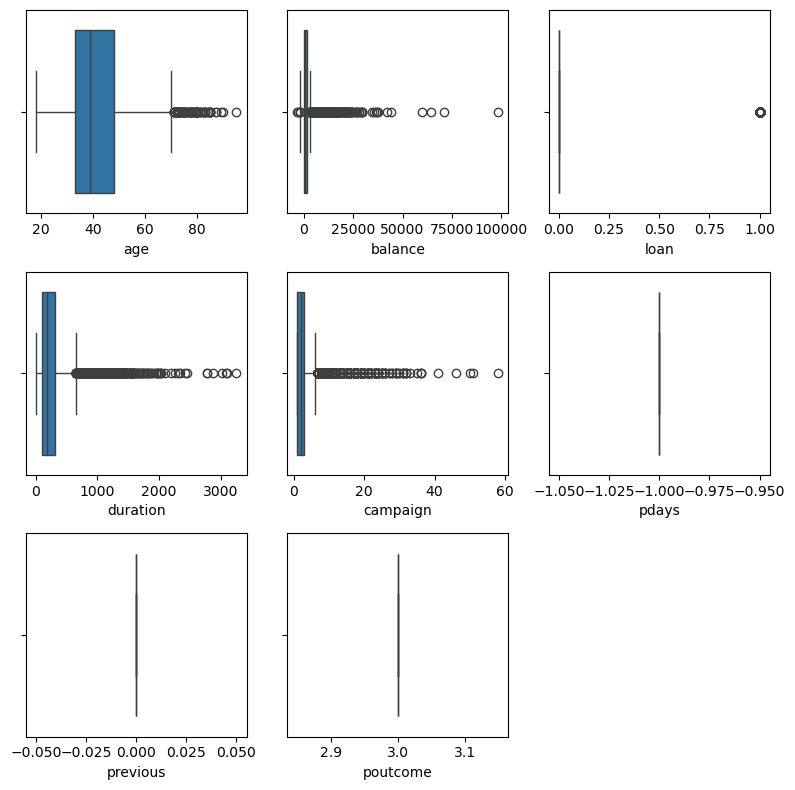

In [106]:
plt.figure(figsize=(8,8))
plt.subplot(3,3,1)
sns.boxplot(x=df_clean["age"])
plt.subplot(3,3,2)
sns.boxplot(x=df_clean["balance"])
plt.subplot(3,3,3)
sns.boxplot(x=df_clean["loan"])
plt.subplot(3,3,4)
sns.boxplot(x=df_clean["duration"])
plt.subplot(3,3,5)
sns.boxplot(x=df_clean["campaign"])
plt.subplot(3,3,6)
sns.boxplot(x=df_clean["pdays"])
plt.subplot(3,3,7)
sns.boxplot(x=df_clean["previous"])
plt.subplot(3,3,8)
sns.boxplot(x=df_clean["poutcome"])
plt.tight_layout()            
plt.show()

Capping

In [109]:
for col in ['age', 'balance', 'loan', 'duration', 'campaign', 'pdays', 'previous', 'poutcome' ]:
    Q1 = df1[col].quantile(0.25)
    Q3 = df1[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_fence = Q1 - 1.5 * IQR
    upper_fence = Q3 + 1.5 * IQR
    capped_col = f'{col}_capped'
    df1[capped_col] = df1[col]
    df1.loc[df1[capped_col] > upper_fence, capped_col] = upper_fence
    df1.loc[df1[capped_col] < lower_fence, capped_col] = lower_fence


<Axes: ylabel='age_capped'>

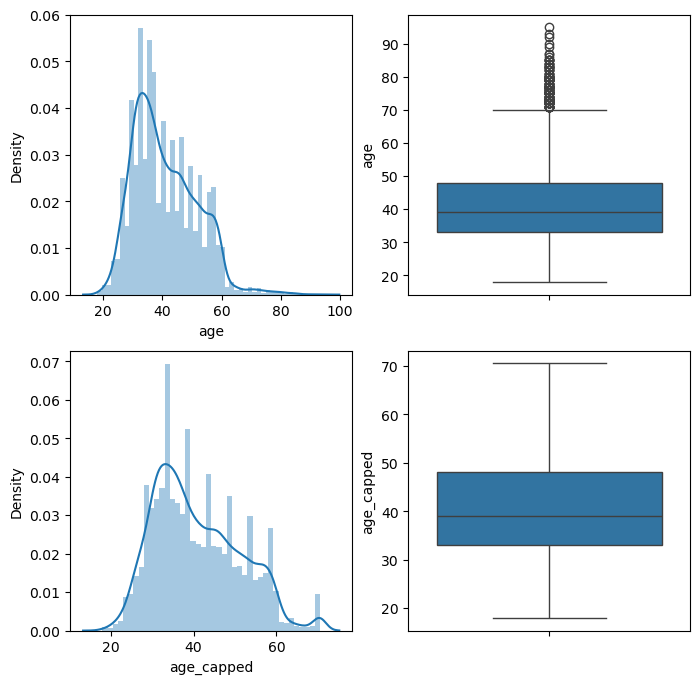

In [111]:
plt.figure(figsize=(8,8))
plt.subplot(2,2,1)
sns.distplot(df1["age"])

plt.subplot(2,2,2)
sns.boxplot(df1["age"])

plt.subplot(2,2,3)
sns.distplot(df1["age_capped"])

plt.subplot(2,2,4)
sns.boxplot(df1["age_capped"])

<Axes: ylabel='balance_capped'>

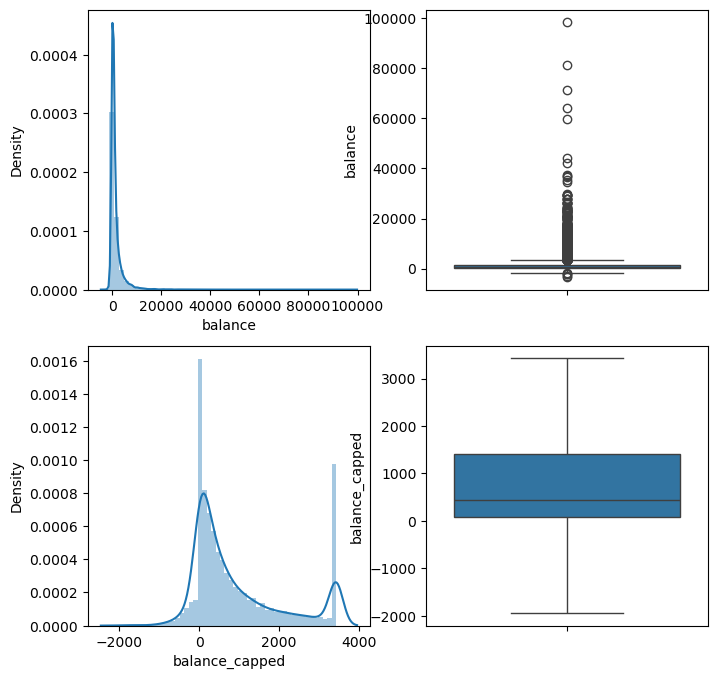

In [112]:
plt.figure(figsize=(8,8))
plt.subplot(2,2,1)
sns.distplot(df1["balance"])

plt.subplot(2,2,2)
sns.boxplot(df1["balance"])

plt.subplot(2,2,3)
sns.distplot(df1["balance_capped"])

plt.subplot(2,2,4)
sns.boxplot(df1["balance_capped"])

<Axes: ylabel='loan_capped'>

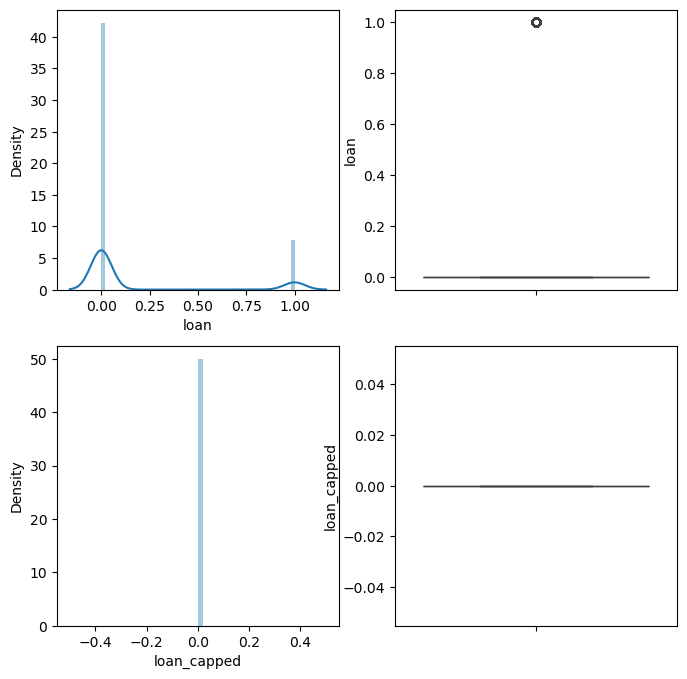

In [114]:
plt.figure(figsize=(8,8))
plt.subplot(2,2,1)
sns.distplot(df1["loan"])

plt.subplot(2,2,2)
sns.boxplot(df1["loan"])

plt.subplot(2,2,3)
sns.distplot(df1["loan_capped"])

plt.subplot(2,2,4)
sns.boxplot(df1["loan_capped"])

<Axes: ylabel='duration_capped'>

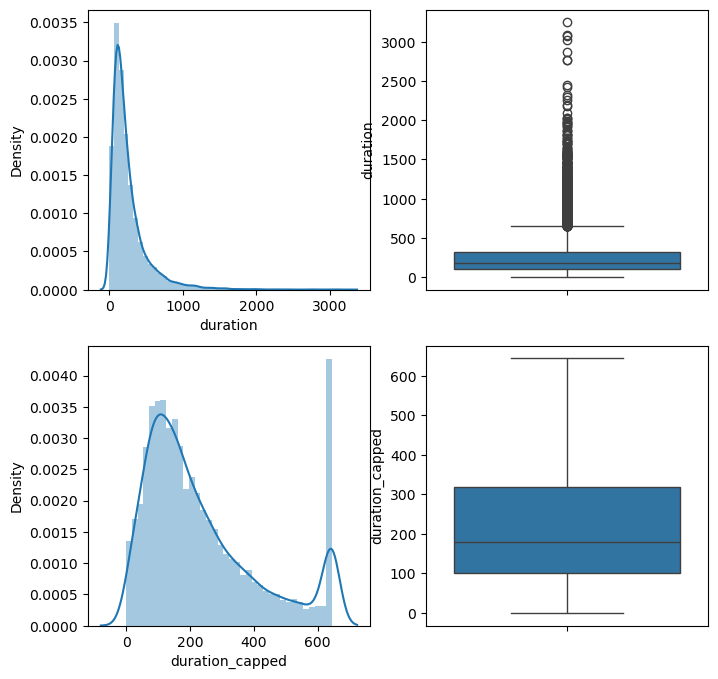

In [115]:
plt.figure(figsize=(8,8))
plt.subplot(2,2,1)
sns.distplot(df1["duration"])

plt.subplot(2,2,2)
sns.boxplot(df1["duration"])

plt.subplot(2,2,3)
sns.distplot(df1["duration_capped"])

plt.subplot(2,2,4)
sns.boxplot(df1["duration_capped"])

<Axes: ylabel='campaign_capped'>

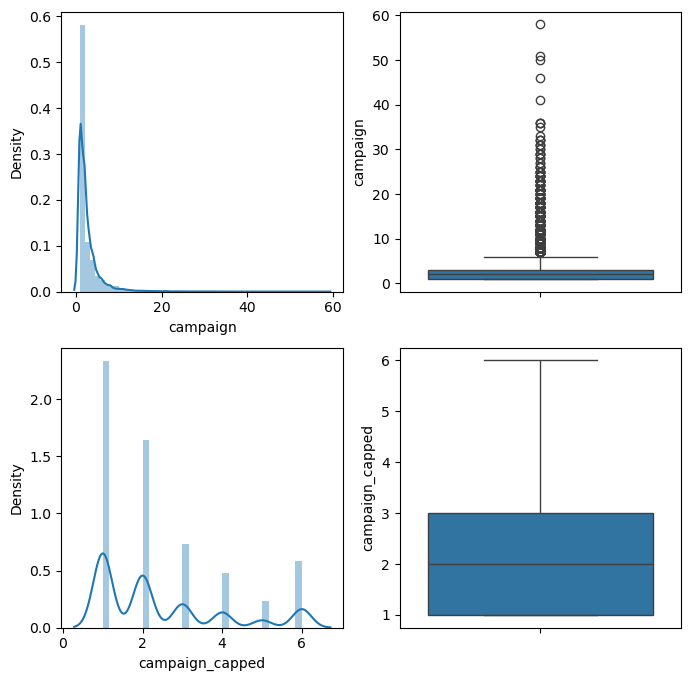

In [117]:
plt.figure(figsize=(8,8))
plt.subplot(2,2,1)
sns.distplot(df1["campaign"])

plt.subplot(2,2,2)
sns.boxplot(df1["campaign"])

plt.subplot(2,2,3)
sns.distplot(df1["campaign_capped"])

plt.subplot(2,2,4)
sns.boxplot(df1["campaign_capped"])

<Axes: ylabel='pdays_capped'>

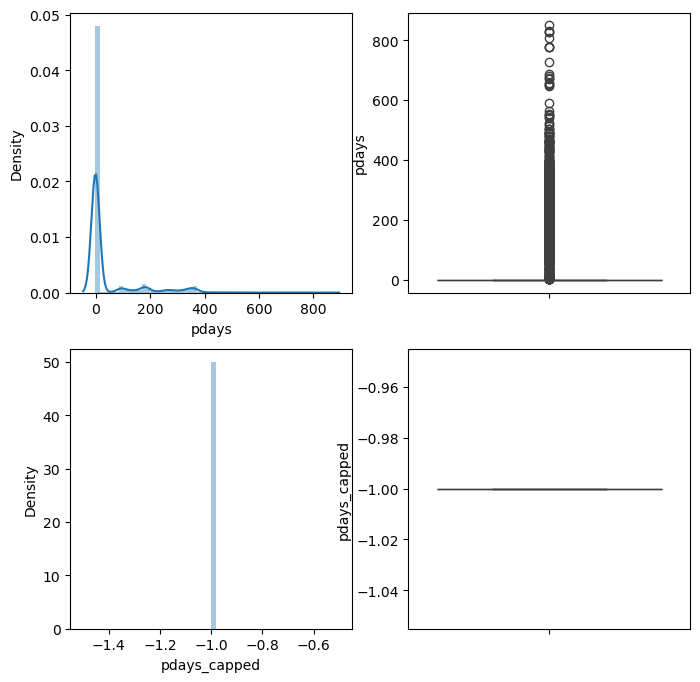

In [119]:
plt.figure(figsize=(8,8))
plt.subplot(2,2,1)
sns.distplot(df1["pdays"])

plt.subplot(2,2,2)
sns.boxplot(df1["pdays"])

plt.subplot(2,2,3)
sns.distplot(df1["pdays_capped"])

plt.subplot(2,2,4)
sns.boxplot(df1["pdays_capped"])

<Axes: ylabel='previous_capped'>

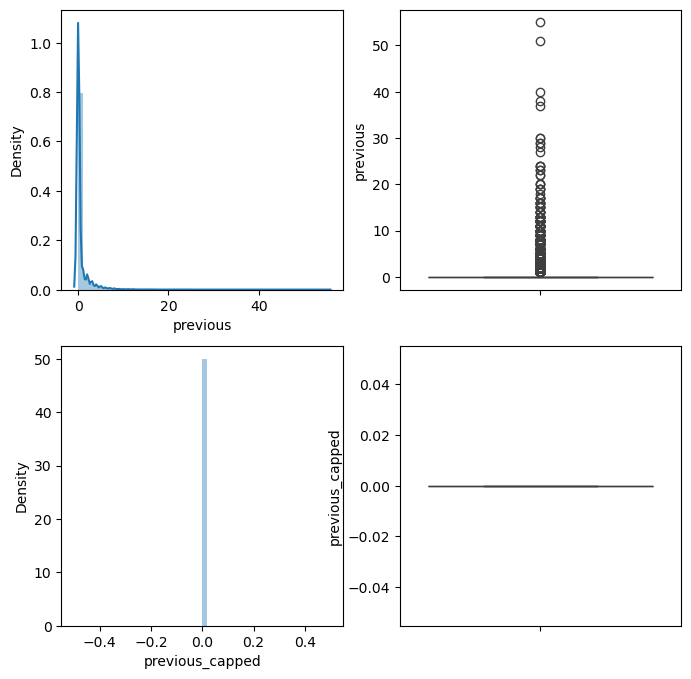

In [123]:
plt.figure(figsize=(8,8))
plt.subplot(2,2,1)
sns.distplot(df1["previous"])

plt.subplot(2,2,2)
sns.boxplot(df1["previous"])

plt.subplot(2,2,3)
sns.distplot(df1["previous_capped"])

plt.subplot(2,2,4)
sns.boxplot(df1["previous_capped"])

<Axes: ylabel='previous_capped'>

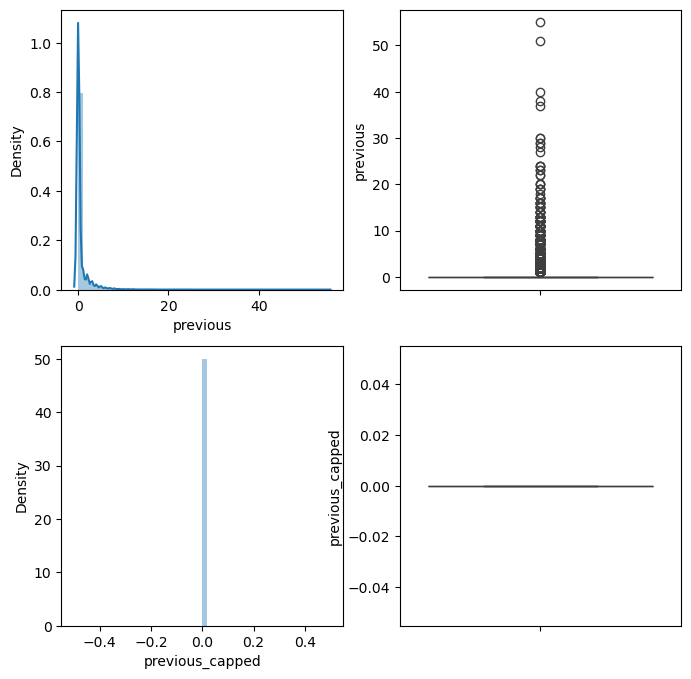

In [125]:
plt.figure(figsize=(8,8))
plt.subplot(2,2,1)
sns.distplot(df1["previous"])

plt.subplot(2,2,2)
sns.boxplot(df1["previous"])

plt.subplot(2,2,3)
sns.distplot(df1["previous_capped"])

plt.subplot(2,2,4)
sns.boxplot(df1["previous_capped"])

<Axes: ylabel='poutcome_capped'>

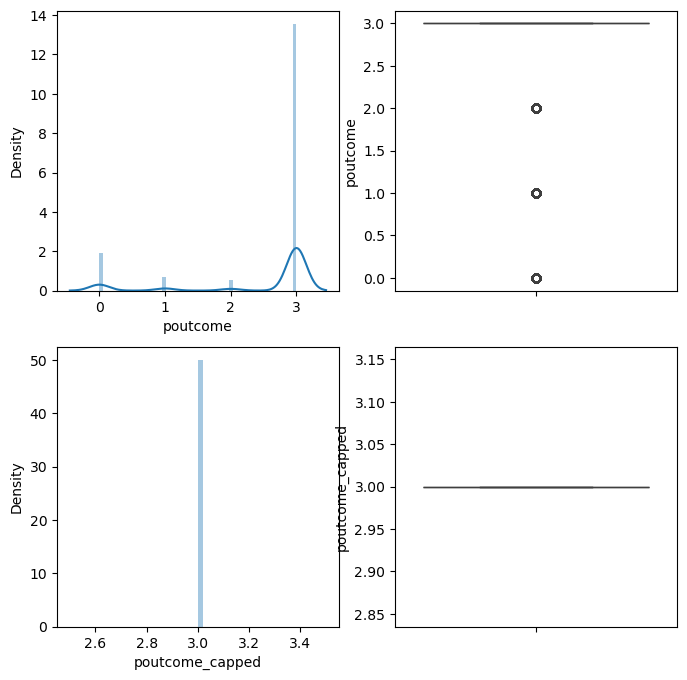

In [127]:
plt.figure(figsize=(8,8))
plt.subplot(2,2,1)
sns.distplot(df1["poutcome"])

plt.subplot(2,2,2)
sns.boxplot(df1["poutcome"])

plt.subplot(2,2,3)
sns.distplot(df1["poutcome_capped"])

plt.subplot(2,2,4)
sns.boxplot(df1["poutcome_capped"])

Feature Scalling

In [130]:
from sklearn.preprocessing import StandardScaler

scaled_cols = ['ID','age','job','marital','education','default', 'balance','housing', 'loan','contact','day','month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome']
scaler = StandardScaler()
scaler_sd = scaler.fit_transform(df[scaled_cols])



In [132]:
scaled_cols1 = ['ID','age','job','marital','education','default', 'balance','housing', 'loan','contact','day','month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome']
scaler = StandardScaler()
scaler_sd1 = scaler.fit_transform(df[scaled_cols1])


In [134]:
df.corr()

,ID,age,job,marital,education,default,balance,housing,loan,contact,...,poutcome,subscribed,age_capped,balance_capped,loan_capped,duration_capped,campaign_capped,pdays_capped,previous_capped,poutcome_capped
ID,1.000000,0.013337,0.061805,0.086454,0.096480,-0.051521,0.067897,-0.180047,-0.086140,-0.723830,...,-0.443429,0.296663,0.004331,0.114890,NaN,0.019050,-0.103263,NaN,NaN,NaN
age,0.013337,1.000000,-0.020765,-0.406024,-0.102356,-0.016117,0.103245,-0.183775,-0.012657,0.026733,...,0.006466,0.024538,0.997271,0.123692,NaN,-0.013173,0.024201,NaN,NaN,NaN
job,0.061805,-0.020765,1.000000,0.066124,0.170347,-0.005217,0.020638,-0.125347,-0.039049,-0.078253,...,0.007101,0.038921,-0.022449,0.026011,NaN,-0.000824,0.005040,NaN,NaN,NaN
marital,0.086454,-0.406024,0.066124,1.000000,0.107547,-0.009591,0.003487,-0.017846,-0.041654,-0.040180,...,-0.019770,0.046043,-0.410032,0.009628,NaN,0.015499,-0.024171,NaN,NaN,NaN
education,0.096480,-0.102356,0.170347,0.107547,1.000000,-0.006774,0.065176,-0.095376,-0.045950,-0.112000,...,-0.019007,0.066051,-0.101171,0.069515,NaN,0.003196,-0.005996,NaN,NaN,NaN
default,-0.051521,-0.016117,-0.005217,-0.009591,-0.006774,1.000000,-0.069422,-0.011823,0.081567,0.014053,...,0.035067,-0.020168,-0.015577,-0.126760,NaN,-0.006787,0.016005,NaN,NaN,NaN
balance,0.067897,0.103245,0.020638,0.003487,0.065176,-0.069422,1.000000,-0.067466,-0.083631,-0.024083,...,-0.019629,0.050807,0.102325,0.693757,NaN,0.023800,-0.016767,NaN,NaN,NaN
housing,-0.180047,-0.183775,-0.125347,-0.017846,-0.095376,-0.011823,-0.067466,1.000000,0.036244,0.195103,...,-0.092677,-0.141092,-0.180563,-0.079410,NaN,0.003575,-0.036880,NaN,NaN,NaN
loan,-0.086140,-0.012657,-0.039049,-0.041654,-0.045950,0.081567,-0.083631,0.036244,1.000000,-0.009213,...,0.010919,-0.072266,-0.010061,-0.117853,NaN,-0.015141,0.005057,NaN,NaN,NaN
contact,-0.723830,0.026733,-0.078253,-0.040180,-0.112000,0.014053,-0.024083,0.195103,-0.009213,1.000000,...,0.272083,-0.150051,0.027939,-0.038937,NaN,-0.025809,0.005853,NaN,NaN,NaN


Heatmap

In [137]:
corr_matrix = df.corr()

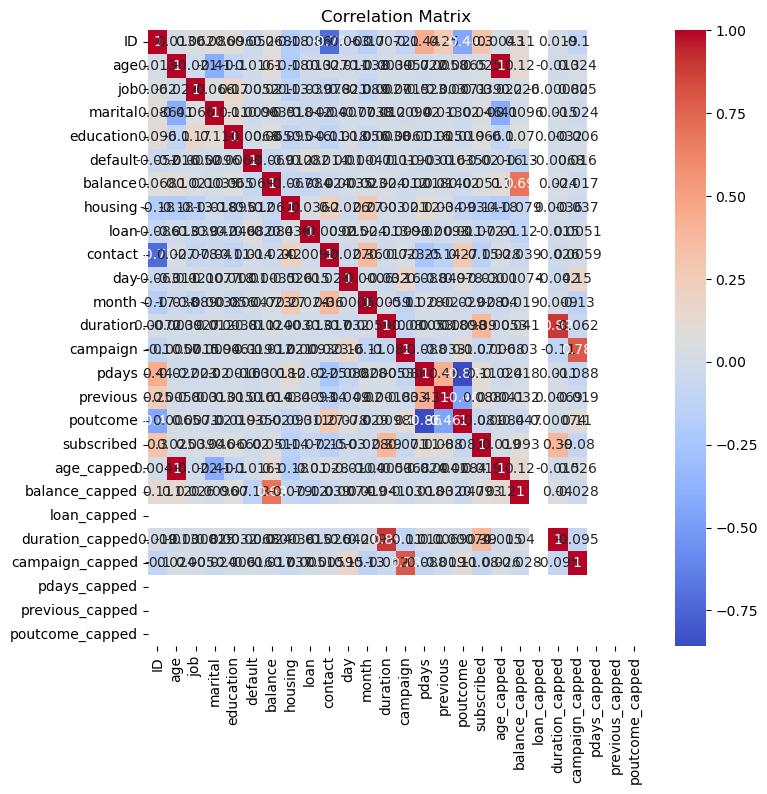

In [139]:
plt.figure(figsize=(8,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()


In [141]:
df1.corr()

,ID,age,job,marital,education,default,balance,housing,loan,contact,...,previous,poutcome,age_capped,balance_capped,loan_capped,duration_capped,campaign_capped,pdays_capped,previous_capped,poutcome_capped
ID,1.000000,0.018874,0.065762,0.070859,0.090366,-0.056901,0.086916,-0.166996,-0.079589,-0.718882,...,0.321845,-0.449871,0.010255,0.110627,NaN,0.035444,-0.110060,NaN,NaN,NaN
age,0.018874,1.000000,-0.024413,-0.396771,-0.117274,-0.022243,0.085246,-0.189573,-0.022863,0.024945,...,-0.011326,0.009334,0.996966,0.118430,NaN,-0.008507,0.023280,NaN,NaN,NaN
job,0.065762,-0.024413,1.000000,0.052579,0.158185,-0.010780,0.012731,-0.125409,-0.018603,-0.090929,...,0.005024,0.020020,-0.026056,0.018996,NaN,0.009444,0.019738,NaN,NaN,NaN
marital,0.070859,-0.396771,0.052579,1.000000,0.110982,-0.000793,-0.000986,-0.012039,-0.059223,-0.036893,...,0.021518,-0.010196,-0.401188,0.003480,NaN,0.013357,-0.019560,NaN,NaN,NaN
education,0.090366,-0.117274,0.158185,0.110982,1.000000,-0.020382,0.063001,-0.080032,-0.054845,-0.108417,...,0.024317,-0.020194,-0.117054,0.062665,NaN,-0.003299,0.008134,NaN,NaN,NaN
default,-0.056901,-0.022243,-0.010780,-0.000793,-0.020382,1.000000,-0.060447,0.008097,0.066402,0.018585,...,-0.025641,0.034386,-0.021866,-0.116393,NaN,-0.006575,0.015423,NaN,NaN,NaN
balance,0.086916,0.085246,0.012731,-0.000986,0.063001,-0.060447,1.000000,-0.071759,-0.086091,-0.034654,...,0.024824,-0.023993,0.083208,0.679022,NaN,0.020314,-0.014691,NaN,NaN,NaN
housing,-0.166996,-0.189573,-0.125409,-0.012039,-0.080032,0.008097,-0.071759,1.000000,0.053394,0.171775,...,0.045626,-0.116616,-0.186658,-0.084185,NaN,0.007825,-0.042905,NaN,NaN,NaN
loan,-0.079589,-0.022863,-0.018603,-0.059223,-0.054845,0.066402,-0.086091,0.053394,1.000000,-0.015035,...,-0.016183,0.025735,-0.020594,-0.124389,NaN,-0.016131,-0.001069,NaN,NaN,NaN
contact,-0.718882,0.024945,-0.090929,-0.036893,-0.108417,0.018585,-0.034654,0.171775,-0.015035,1.000000,...,-0.168726,0.272425,0.026211,-0.032536,NaN,-0.041134,0.000495,NaN,NaN,NaN


Heatmap

In [148]:
corr_matrix1 = df.corr()

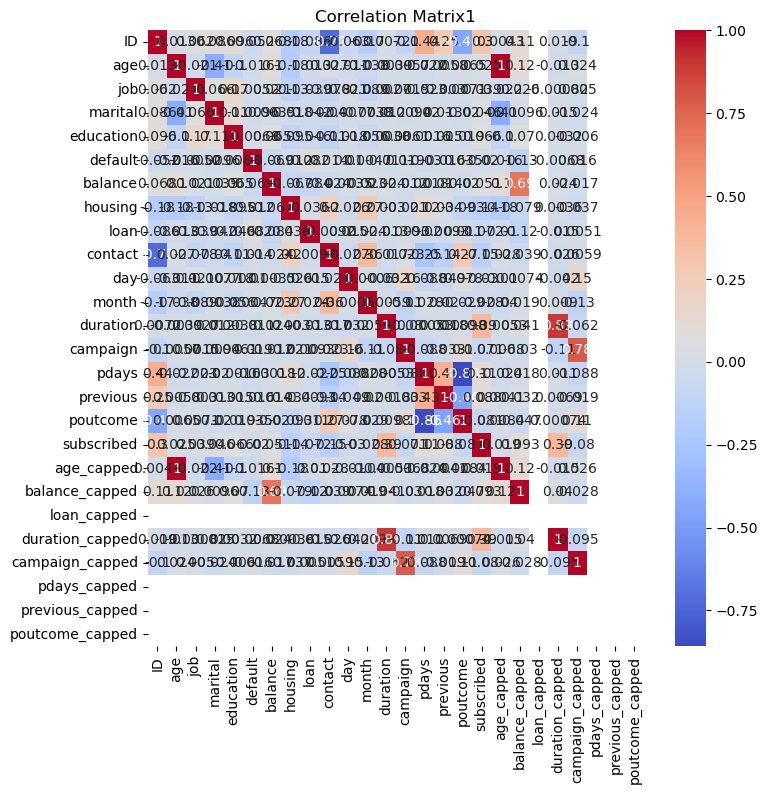

In [150]:
plt.figure(figsize=(8,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix1")
plt.show()


In [152]:
print(df.columns)

Index(['ID', 'age', 'job', 'marital', 'education', 'default', 'balance',
       'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign',
       'pdays', 'previous', 'poutcome', 'subscribed', 'age_capped',
       'balance_capped', 'loan_capped', 'duration_capped', 'campaign_capped',
       'pdays_capped', 'previous_capped', 'poutcome_capped'],
      dtype='object')


In [154]:
print(df1.columns)

Index(['ID', 'age', 'job', 'marital', 'education', 'default', 'balance',
       'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign',
       'pdays', 'previous', 'poutcome', 'age_capped', 'balance_capped',
       'loan_capped', 'duration_capped', 'campaign_capped', 'pdays_capped',
       'previous_capped', 'poutcome_capped'],
      dtype='object')


Feature Selection

In [157]:
from sklearn.feature_selection import SelectKBest, f_classif

# Convert scaled array to DataFrame
X = pd.DataFrame(scaler_sd, columns=scaled_cols)

y = df['subscribed']

selector = SelectKBest(score_func=f_classif, k=5)
X_new = selector.fit_transform(X, y)

# Get selected feature names
selected_features = X.columns[selector.get_support()]
print(selected_features)



Index(['ID', 'housing', 'contact', 'duration', 'pdays'], dtype='object')


In [159]:
x=df.drop("subscribed",axis=1)
y=df["subscribed"]


Logistic Regression

In [162]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [164]:
x_train.shape,x_test.shape

((25317, 25), (6330, 25))

In [166]:
from sklearn.linear_model import LogisticRegression

In [168]:
#create model
model = LogisticRegression()
model.fit(x_train, y_train)


LogisticRegression()

In [170]:
#make prediction
y_pred=model.predict(x_test)

In [172]:
print(y_pred)

[0 0 0 ... 0 0 0]


Evaluate the model

In [175]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)


Accuracy: 0.8867298578199052

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.97      0.94      5599
           1       0.52      0.21      0.30       731

    accuracy                           0.89      6330
   macro avg       0.71      0.59      0.62      6330
weighted avg       0.86      0.89      0.87      6330

Confusion Matrix:
 [[5456  143]
 [ 574  157]]


<Figure size 800x800 with 0 Axes>

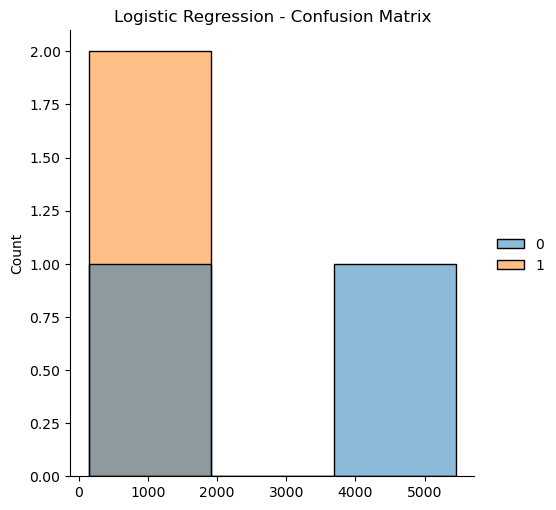

In [177]:
plt.figure(figsize=(8,8))
sns.displot(cm,color='sky Blue')
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

Decision Tree

In [180]:
#create model
from sklearn.tree import DecisionTreeClassifier
model_dt = DecisionTreeClassifier()
model_dt.fit(x_train, y_train)


DecisionTreeClassifier()

In [182]:
#make prediction
pred_dt = model_dt.predict(x_test)

In [184]:
pred_dt

array([0, 0, 0, ..., 1, 0, 0])

Evaluate the model

In [187]:
acc = accuracy_score(y_test, pred_dt)
print("Accuracy:", acc)
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.8824644549763033

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.97      0.94      5599
           1       0.52      0.21      0.30       731

    accuracy                           0.89      6330
   macro avg       0.71      0.59      0.62      6330
weighted avg       0.86      0.89      0.87      6330


Confusion Matrix:
 [[5456  143]
 [ 574  157]]


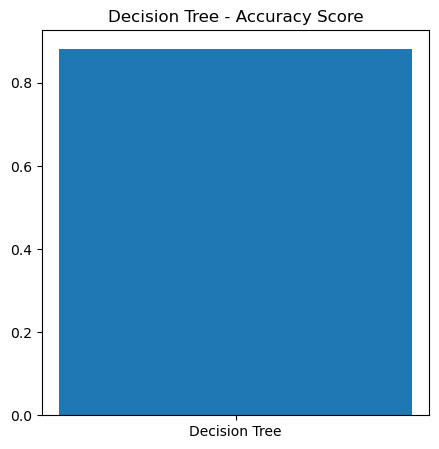

In [189]:
plt.figure(figsize=(5,5))
plt.bar(["Decision Tree"], [acc])
plt.title("Decision Tree - Accuracy Score")
plt.show()



RandomForest

In [192]:
from sklearn.ensemble import RandomForestClassifier
#create model
model_rf = RandomForestClassifier()
model_rf.fit(x_train, y_train)

RandomForestClassifier()

In [194]:
#make prediction
pred_rf = model_rf.predict(x_test)

In [196]:
pred_rf

array([0, 0, 0, ..., 0, 0, 0])

Evaluate the model

In [199]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)


Accuracy: 0.8867298578199052

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.97      0.94      5599
           1       0.52      0.21      0.30       731

    accuracy                           0.89      6330
   macro avg       0.71      0.59      0.62      6330
weighted avg       0.86      0.89      0.87      6330

Confusion Matrix:
 [[5456  143]
 [ 574  157]]


<Figure size 800x800 with 0 Axes>

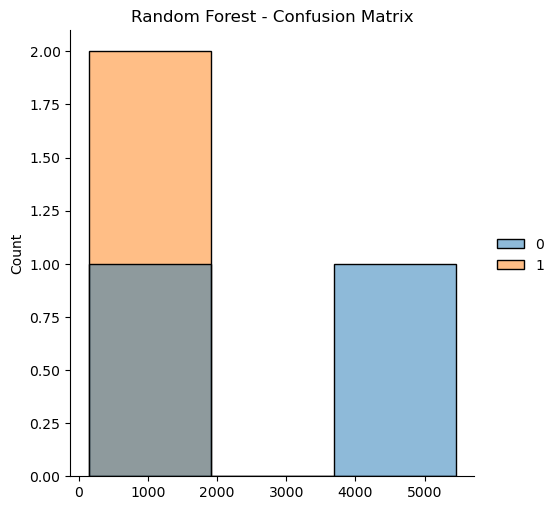

In [201]:
plt.figure(figsize=(8,8))
sns.displot(cm,color='Blue')
plt.title("Random Forest - Confusion Matrix")
plt.show()

Support Vector Machine (SVM)

In [204]:
from sklearn.svm import SVC
#create model
model_svm = SVC()
model_svm.fit(x_train, y_train)


SVC()

In [206]:
#make prediction
pred_svm = model_svm.predict(x_test)

In [207]:
pred_svm

array([0, 0, 0, ..., 0, 0, 0])

Evaluate the model

In [211]:
print("Accuracy:", accuracy_score(y_test, y_pred))
cf=classification_report(y_test, y_pred)
print("\nClassification Report:\n",cf)
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.8867298578199052

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.97      0.94      5599
           1       0.52      0.21      0.30       731

    accuracy                           0.89      6330
   macro avg       0.71      0.59      0.62      6330
weighted avg       0.86      0.89      0.87      6330

Confusion Matrix:
 [[5456  143]
 [ 574  157]]


<Figure size 800x800 with 0 Axes>

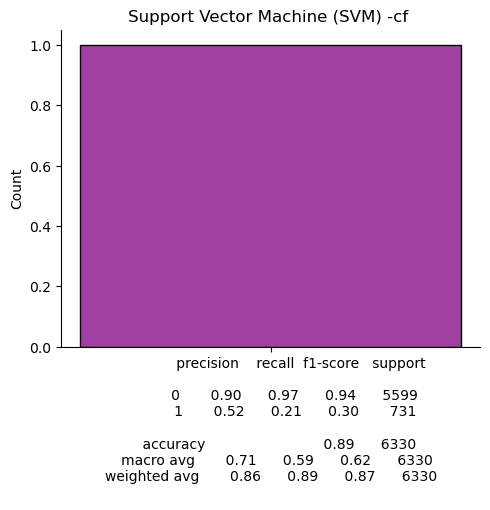

In [213]:
plt.figure(figsize=(8,8))
sns.displot(cf,color='purple')
plt.title("Support Vector Machine (SVM) -cf ")
plt.show()

K-Nearest Neighbors (KNN)

In [216]:
from sklearn.neighbors import KNeighborsClassifier
#create model
model_knn = KNeighborsClassifier()
model_knn.fit(x_train, y_train)



KNeighborsClassifier()

In [218]:
#make prediction
pred_knn = model_knn.predict(x_test)

In [219]:
pred_knn

array([0, 0, 0, ..., 0, 0, 0])

Evaluate the model

In [223]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)


Accuracy: 0.8867298578199052

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.97      0.94      5599
           1       0.52      0.21      0.30       731

    accuracy                           0.89      6330
   macro avg       0.71      0.59      0.62      6330
weighted avg       0.86      0.89      0.87      6330

Confusion Matrix:
 [[5456  143]
 [ 574  157]]


<Figure size 800x800 with 0 Axes>

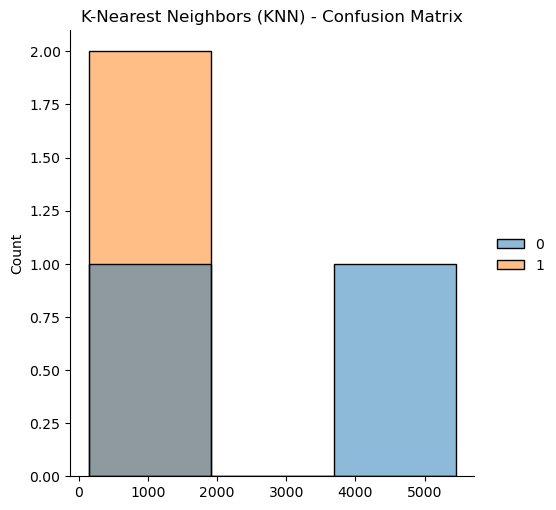

In [225]:
plt.figure(figsize=(8,8))
sns.displot(cm,color='pink')
plt.title("K-Nearest Neighbors (KNN) - Confusion Matrix")
plt.show()

XGBClassifier

In [228]:
from xgboost import XGBClassifier

In [230]:
#create model
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
xgb_model.fit(x_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [232]:
#make prediction
y_pred = xgb_model.predict(x_test)

In [234]:
y_pred

array([0, 0, 0, ..., 0, 0, 0])

Evaluate Model

In [237]:
print("Accuracy:",accuracy_score(y_test,y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
cm=(confusion_matrix(y_test, y_pred))
print("\nConfusion Matrix:\n", cm)

Accuracy: 0.9101105845181675

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.95      0.95      5599
           1       0.62      0.57      0.59       731

    accuracy                           0.91      6330
   macro avg       0.78      0.76      0.77      6330
weighted avg       0.91      0.91      0.91      6330


Confusion Matrix:
 [[5347  252]
 [ 317  414]]


<Figure size 800x800 with 0 Axes>

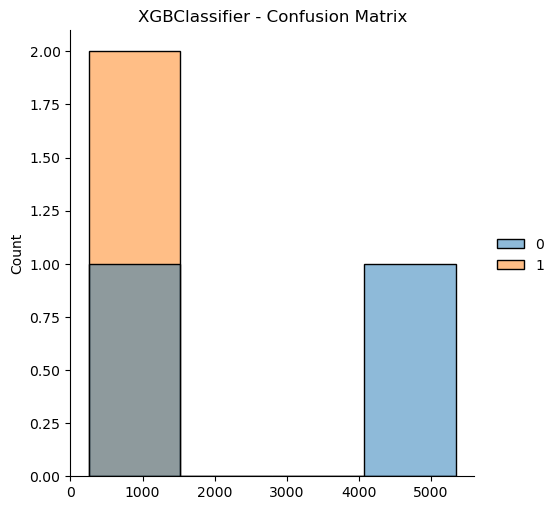

In [239]:
plt.figure(figsize=(8,8))
sns.displot(cm,color='pink')
plt.title("XGBClassifier - Confusion Matrix")
plt.show()

Random Forest Hyperparameter Tuning

In [244]:
from sklearn.preprocessing import StandardScaler

preprocess = StandardScaler()
preprocess.fit(x_train)

x_train_trans = preprocess.transform(x_train)
x_test_trans = preprocess.transform(x_test)


In [246]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

random_search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

random_search.fit(x_train_trans, y_train)

print("Best Params:", random_search.best_params_)
print("Best Score:", random_search.best_score_)


Best Params: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 20}
Best Score: 0.9108109175652723


Create Preprocessing + Model Pipeline

In [249]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
import pickle

# Select features and target
features = ['age','balance','duration','campaign','pdays','previous']
target = 'subscribed'

X = df[features]
y = df[target]

# Create Pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier())
])

# Train pipeline
pipeline.fit(X, y)

# Save entire pipeline
with open("bank_pipeline.pkl", "wb") as f:
    pickle.dump(pipeline, f)

print("Pipeline saved successfully!")

Pipeline saved successfully!


In [251]:
import numpy as np
import pickle

# Load pipeline
with open("bank_pipeline.pkl", "rb") as f:
    loaded_pipeline = pickle.load(f)

# Input data (must follow feature order)
data = (30, 5000, 120, 2, 100, 1)

# Convert to array
data_array = np.asarray(data).reshape(1, -1)

# Predict
prediction = loaded_pipeline.predict(data_array)

print("Prediction:", prediction[0])


Prediction: 0
